# Movie Recommender System

**Name:** Devitha P S

**Organization:** Entri Elevate

**Date:** 28-07-2026

### **-- Overview of Problem Statement ---**
In today's vast and ever-growing landscape of movies, users often struggle to discover content that aligns with their personal tastes and preferences. Existing platforms may offer generic recommendations or rely on limited filtering options, leading to user fatigue and missed opportunities for engagement. The challenge is to develop a robust and intelligent movie recommendation system that can accurately predict user preferences and deliver personalized suggestions, thereby enhancing user experience and increasing content consumption.

### **--- Objective ---**
The primary objective of this project is to develop and implement an effective movie recommendation system that leverages machine learning techniques to provide personalized movie suggestions to users. This system aims to:

*   **Enhance User Experience:** By delivering highly relevant and tailored movie recommendations, improving user satisfaction and engagement with the platform.
*   **Increase Content Discovery:** Enable users to efficiently explore and find new movies that match their individual preferences, reducing decision fatigue.
*   **Improve Recommendation Accuracy:** Utilize advanced algorithms to analyze user data, movie attributes, and interaction patterns to generate precise and diverse recommendations.
*   **Scalability:** Design a system that can handle a large volume of movies and users, providing timely recommendations as the dataset grows.

### **--- Data Collection and Initial Exploration ---**

This section handles the loading of our datasets movies.csv and ratings.csv, essential library imports, and a first look at the data's structure and content.

In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import mean_squared_error

# Upload the datasets named movies.csv and ratings.csv
from google.colab import files
print("Please upload 'movie.csv':")
files.upload()
print("Please upload 'rating.csv':")
files.upload()

# Read the datasets
movies = pd.read_csv('movie.csv')
ratings = pd.read_csv('rating.csv')

print("Movies DataFrame head:")
display(movies.head())

print("\nRatings DataFrame head:")
display(ratings.head())

print(f"\nUnique users: {ratings['userId'].nunique()}")
print(f"Unique movies: {ratings['movieId'].nunique()}")

Please upload 'movie.csv':


Saving movie.csv to movie.csv
Please upload 'rating.csv':


Saving rating.csv to rating.csv
Movies DataFrame head:


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy



Ratings DataFrame head:


,userId,movieId,rating,timestamp
0,1,2,3.5,02-04-2005 23:53
1,1,29,3.5,02-04-2005 23:31
2,1,32,3.5,02-04-2005 23:33
3,1,47,3.5,02-04-2005 23:32
4,1,50,3.5,02-04-2005 23:29



Unique users: 375
Unique movies: 6566


### Data Preprocessing - Data Cleaning

Before proceeding with collaborative filtering, it's essential to clean our raw movies and ratings datasets. This involves checking for and handling missing values, duplicates, and ensuring correct data types. While some cleaning is handled implicitly (e.g., filling NaNs in the user-item matrix), an explicit step here ensures data quality from the start.

In [2]:
# 1. Check for missing values in original 'movies' and 'ratings' DataFrames
print("\nMissing values in movies DataFrame:")
display(movies.isnull().sum())

print("\nMissing values in ratings DataFrame:")
display(ratings.isnull().sum())


Missing values in movies DataFrame:


,0
movieId,0
title,0
genres,0



Missing values in ratings DataFrame:


,0
userId,0
movieId,0
rating,0
timestamp,0


Reviewing the missing values helps us understand if there are any gaps in our data. 'timestamp' often doesn't have missing values as it's typically auto-generated. 'genres' might have missing values or 'no genres listed' which need specific handling. For now, we'll proceed assuming minimal critical missing data that would break the merge.

In [3]:
# 2. Check for duplicate entries
print("\nDuplicate rows in movies DataFrame:", movies.duplicated().sum())
print("Duplicate rows in ratings DataFrame:", ratings.duplicated().sum())

# Drop duplicates if any (though usually movieId is unique and userId-movieId pairs are unique in ratings)
if movies.duplicated().sum() > 0:
    print("Dropping duplicate rows in movies DataFrame.")
    movies.drop_duplicates(inplace=True)

# For ratings, duplicates would mean a user rated the same movie multiple times
# We'll drop these, keeping the last rating in case of multiple entries.
if ratings.duplicated().sum() > 0:
    print("Dropping duplicate rows in ratings DataFrame.")
    ratings.drop_duplicates(inplace=True)

print("\nAfter dropping duplicates:")
print("Duplicate rows in movies DataFrame:", movies.duplicated().sum())
print("Duplicate rows in ratings DataFrame:", ratings.duplicated().sum())


Duplicate rows in movies DataFrame: 0
Duplicate rows in ratings DataFrame: 0

After dropping duplicates:
Duplicate rows in movies DataFrame: 0
Duplicate rows in ratings DataFrame: 0


Removing duplicate entries ensures that each record is unique and doesn't artificially inflate counts or distort statistics. For ratings, if a user rates the same movie multiple times, we typically decide on a strategy (e.g., take the latest rating, average ratings, or simply drop duplicates keeping one).

In [4]:
# 3. Ensure correct data types (if necessary)

# First, drop rows with any missing values, as seen at the end of the ratings DataFrame
# This also helps ensure userId and movieId can be converted to integer types
initial_rows = ratings.shape[0]
ratings.dropna(inplace=True)
dropped_rows = initial_rows - ratings.shape[0]
if dropped_rows > 0:
    print(f"Dropped {dropped_rows} rows from ratings DataFrame due to missing values.")

# Convert userId and movieId to integer type
if not pd.api.types.is_integer_dtype(ratings['userId']):
    print("Converting 'userId' column to integer in ratings DataFrame.")
    ratings['userId'] = ratings['userId'].astype(int)

if not pd.api.types.is_integer_dtype(ratings['movieId']):
    print("Converting 'movieId' column to integer in ratings DataFrame.")
    ratings['movieId'] = ratings['movieId'].astype(int)

# The 'timestamp' column was read as object in previous cells. Let's convert it to datetime.
if not pd.api.types.is_datetime64_any_dtype(ratings['timestamp']):
    print("Converting 'timestamp' column to datetime in ratings DataFrame.")
    # The format observed in the error message is DD-MM-YYYY HH:MM
    ratings['timestamp'] = pd.to_datetime(ratings['timestamp'], format='%d-%m-%Y %H:%M')
else:
    print("'timestamp' column is already of datetime type.")

print("\nData types after cleaning:")
display(movies.info())
display(ratings.info())

Converting 'timestamp' column to datetime in ratings DataFrame.

Data types after cleaning:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27278 entries, 0 to 27277
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  27278 non-null  int64 
 1   title    27278 non-null  object
 2   genres   27278 non-null  object
dtypes: int64(1), object(2)
memory usage: 639.5+ KB


None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50840 entries, 0 to 50839
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   userId     50840 non-null  int64         
 1   movieId    50840 non-null  int64         
 2   rating     50840 non-null  float64       
 3   timestamp  50840 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(2)
memory usage: 1.6 MB


None

Correct data types are crucial for proper analysis and operations. Converting 'timestamp' to datetime objects allows for time-based analysis if needed. Now that the raw dataframes are cleaned, we can proceed with merging them for collaborative filtering, as was done in previous steps.

### Feature Engineering

From the timestamp column, we can extract several time-based features such as the year, month, and day of the week. These can capture temporal patterns in user ratings.

In [5]:
movie_ratings = pd.merge(ratings, movies, on='movieId', how='left')

# Extract time-based features from 'timestamp'
movie_ratings['rating_year'] = movie_ratings['timestamp'].dt.year
movie_ratings['rating_month'] = movie_ratings['timestamp'].dt.month
movie_ratings['rating_day_of_week'] = movie_ratings['timestamp'].dt.dayofweek

print("Movie Ratings DataFrame with new time features:")
display(movie_ratings.head())

Movie Ratings DataFrame with new time features:


,userId,movieId,rating,timestamp,title,genres,rating_year,rating_month,rating_day_of_week
0,1,2,3.5,2005-04-02 23:53:00,Jumanji (1995),Adventure|Children|Fantasy,2005,4,5
1,1,29,3.5,2005-04-02 23:31:00,"City of Lost Children, The (Cité des enfants p...",Adventure|Drama|Fantasy|Mystery|Sci-Fi,2005,4,5
2,1,32,3.5,2005-04-02 23:33:00,Twelve Monkeys (a.k.a. 12 Monkeys) (1995),Mystery|Sci-Fi|Thriller,2005,4,5
3,1,47,3.5,2005-04-02 23:32:00,Seven (a.k.a. Se7en) (1995),Mystery|Thriller,2005,4,5
4,1,50,3.5,2005-04-02 23:29:00,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,2005,4,5


The genres column contains multiple genres separated by '|'. To use these in a model, we can perform one-hot encoding, creating a new binary column for each unique genre. This transforms the categorical genre information into a numerical format suitable for machine learning.

In [6]:
# One-hot encode genres
# First, handle 'no genres listed' by replacing it with a more consistent empty string for splitting
movies_temp = movies.copy()
movies_temp['genres'] = movies_temp['genres'].replace('(no genres listed)', '')

# Create a list of all unique genres
all_genres = set()
for genres_str in movies_temp['genres'].str.split('|'):
    for genre in genres_str:
        if genre: # Avoid adding empty strings from split
            all_genres.add(genre)

# Create binary columns for each genre
for genre in all_genres:
    movies_temp[genre] = movies_temp['genres'].apply(lambda x: 1 if genre in x else 0)

# Merge these new genre features back into movie_ratings
movie_ratings = pd.merge(movie_ratings, movies_temp.drop(columns=['title', 'genres']), on='movieId', how='left')

print("Movie Ratings DataFrame with one-hot encoded genres:")
display(movie_ratings.head())

Movie Ratings DataFrame with one-hot encoded genres:


,userId,movieId,rating,timestamp,title,genres,rating_year,rating_month,rating_day_of_week,Musical,...,Animation,Crime,Western,Film-Noir,IMAX,Adventure,Comedy,Romance,Sci-Fi,Drama
0,1,2,3.5,2005-04-02 23:53:00,Jumanji (1995),Adventure|Children|Fantasy,2005,4,5,0,...,0,0,0,0,0,1,0,0,0,0
1,1,29,3.5,2005-04-02 23:31:00,"City of Lost Children, The (Cité des enfants p...",Adventure|Drama|Fantasy|Mystery|Sci-Fi,2005,4,5,0,...,0,0,0,0,0,1,0,0,1,1
2,1,32,3.5,2005-04-02 23:33:00,Twelve Monkeys (a.k.a. 12 Monkeys) (1995),Mystery|Sci-Fi|Thriller,2005,4,5,0,...,0,0,0,0,0,0,0,0,1,0
3,1,47,3.5,2005-04-02 23:32:00,Seven (a.k.a. Se7en) (1995),Mystery|Thriller,2005,4,5,0,...,0,0,0,0,0,0,0,0,0,0
4,1,50,3.5,2005-04-02 23:29:00,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,2005,4,5,0,...,0,1,0,0,0,0,0,0,0,0


These newly engineered features (rating_year, rating_month, rating_day_of_week, and the one-hot encoded genre columns) can now be used as input for more advanced recommendation models or for further analysis.

### Exploratory Data Analysis - Further Insights

#### 1. Distribution of Movie Genres

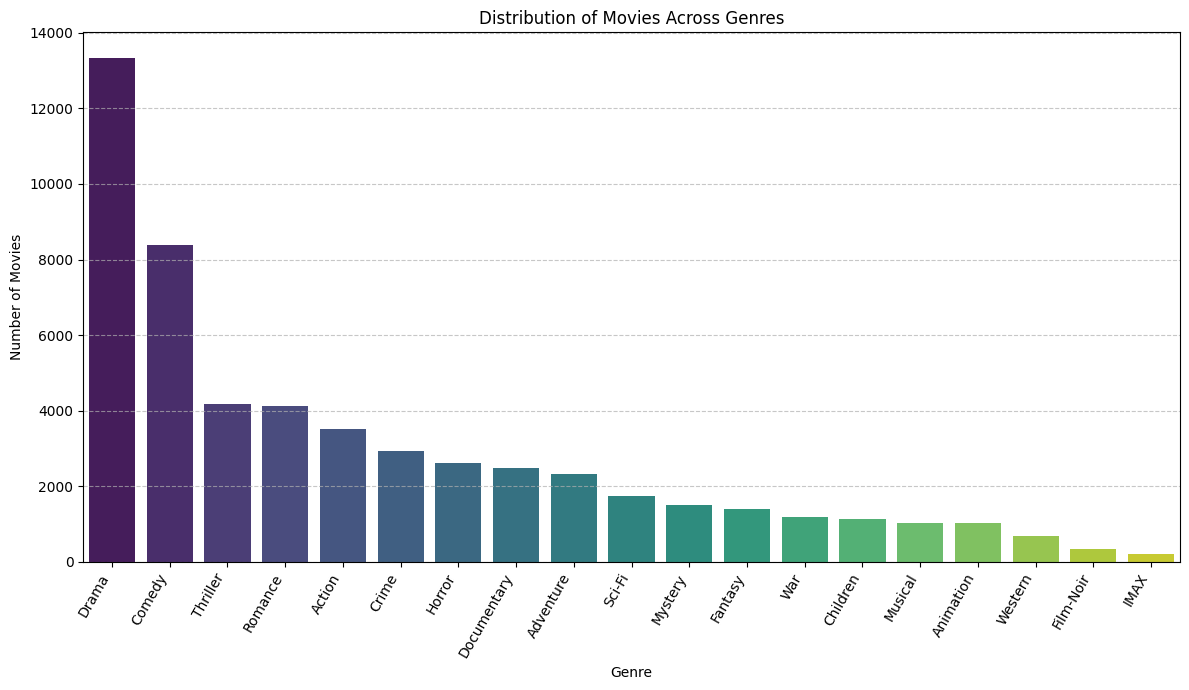

In [7]:
genre_counts = movies_temp.drop(columns=['movieId', 'title', 'genres']).sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(x=genre_counts.index, y=genre_counts.values, palette='viridis', ax=ax, hue=genre_counts.index, legend=False)
plt.title('Distribution of Movies Across Genres')
plt.xlabel('Genre')
plt.ylabel('Number of Movies')
plt.xticks(rotation=60, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### 2. Average Rating by Genre

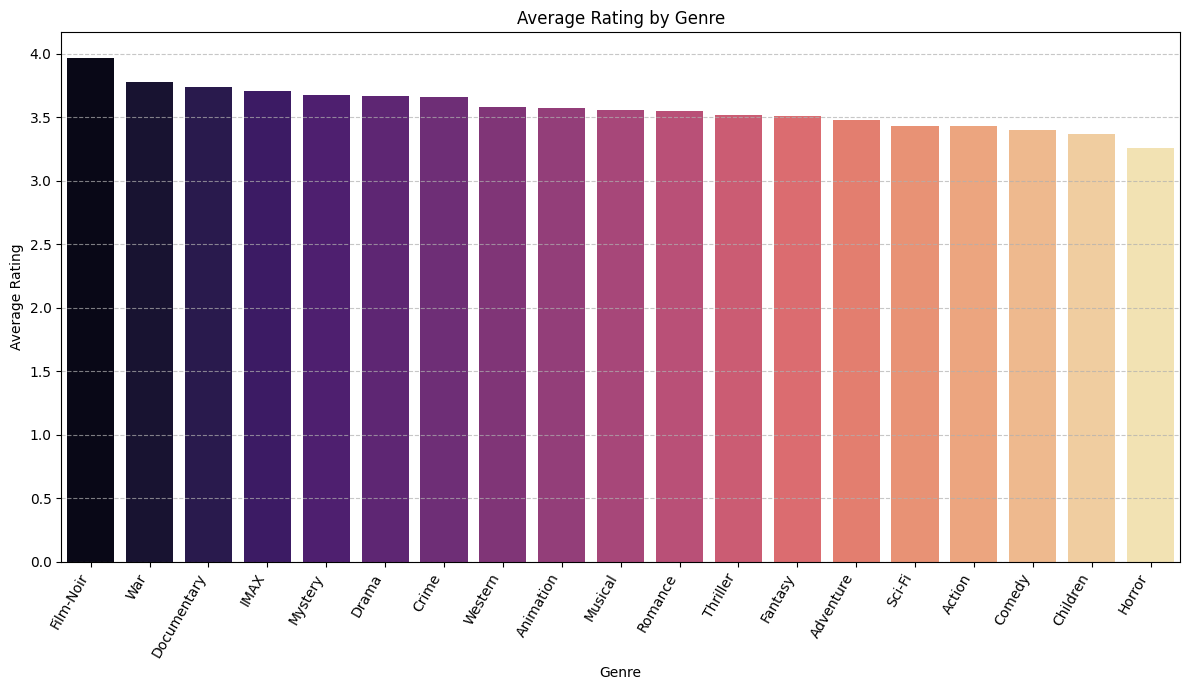

In [8]:
# Calculate average rating for each genre
genre_avg_ratings = {} # Initialize empty dict to hold genre average ratings

# Get all unique genres from movie_ratings after one-hot encoding
# Filter out non-genre columns to iterate only over genre columns
genre_cols = [col for col in movie_ratings.columns if col not in ['userId', 'movieId', 'rating', 'timestamp', 'title', 'genres', 'rating_year', 'rating_month', 'rating_day_of_week']]

for genre in genre_cols:
    # Filter movie_ratings to include only movies belonging to the current genre
    # Then calculate the mean of 'rating' for those movies
    genre_avg_ratings[genre] = movie_ratings[movie_ratings[genre] == 1]['rating'].mean()

# Convert the dictionary to a Series for easier plotting and sorting
genre_avg_ratings_series = pd.Series(genre_avg_ratings).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(x=genre_avg_ratings_series.index, y=genre_avg_ratings_series.values, palette='magma', ax=ax, hue=genre_avg_ratings_series.index, legend=False)
plt.title('Average Rating by Genre')
plt.xlabel('Genre')
plt.ylabel('Average Rating')
plt.xticks(rotation=60, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### 3. Average Rating Over Time

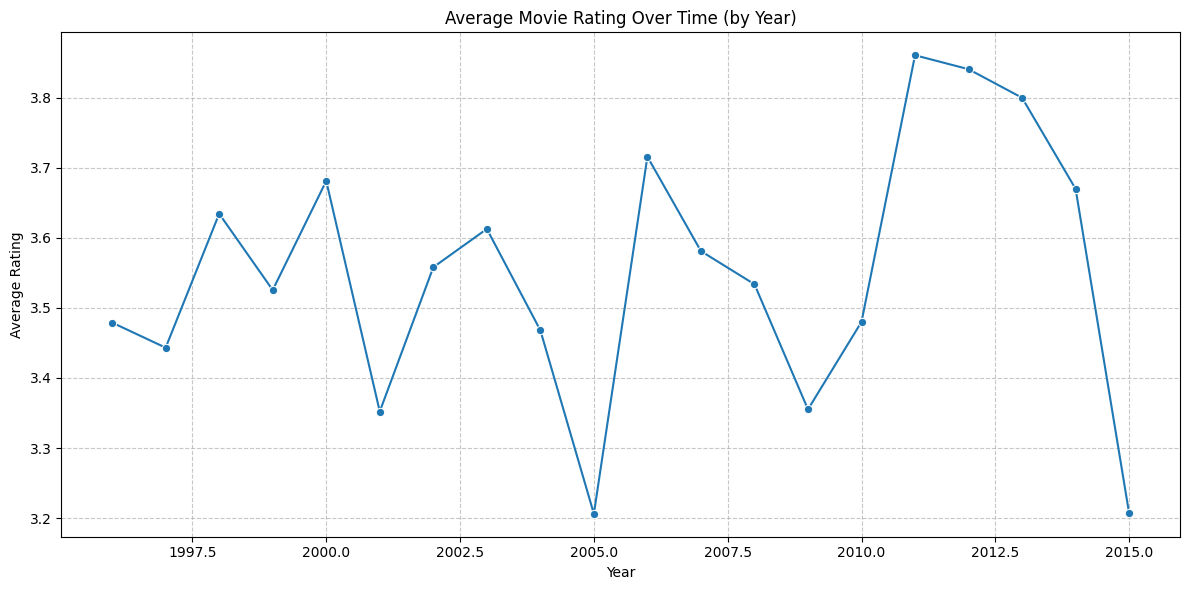

In [9]:
avg_ratings_per_year = movie_ratings.groupby('rating_year')['rating'].mean().reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(x='rating_year', y='rating', data=avg_ratings_per_year, marker='o', ax=ax)
plt.title('Average Movie Rating Over Time (by Year)')
plt.xlabel('Year')
plt.ylabel('Average Rating')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Data Splitting for Collaborative Filtering

For collaborative filtering, it's common to split the user-item interaction data (ratings) into training and testing sets. This allows us to train the model on a portion of the data and then evaluate its ability to predict ratings for the unseen interactions in the test set. We'll perform a random 80/20 split of the movie_ratings DataFrame.

In [10]:
from sklearn.model_selection import train_test_split

# Split the movie_ratings DataFrame into training and testing sets
# We're splitting the entire DataFrame, which contains all features including userId, movieId, and rating
train_data, test_data = train_test_split(movie_ratings, test_size=0.2, random_state=42)

print("Shape of training data:", train_data.shape)
print("Shape of testing data:", test_data.shape)

display(train_data.head())
display(test_data.head())

Shape of training data: (40672, 28)
Shape of testing data: (10168, 28)


,userId,movieId,rating,timestamp,title,genres,rating_year,rating_month,rating_day_of_week,Musical,...,Animation,Crime,Western,Film-Noir,IMAX,Adventure,Comedy,Romance,Sci-Fi,Drama
44122,340,64620,4.0,2009-07-11 22:23:00,Frost/Nixon (2008),Drama,2009,7,5,0,...,0,0,0,0,0,0,0,0,0,1
20549,156,1873,4.0,2002-11-26 20:05:00,"Misérables, Les (1998)",Crime|Drama|Romance|War,2002,11,1,0,...,0,1,0,0,0,0,0,1,0,1
48553,363,551,5.0,2000-12-08 23:33:00,"Nightmare Before Christmas, The (1993)",Animation|Children|Fantasy|Musical,2000,12,4,1,...,1,0,0,0,0,0,0,0,0,0
28465,220,8366,3.5,2004-11-27 02:09:00,Saved! (2004),Comedy|Drama,2004,11,5,0,...,0,0,0,0,0,0,1,0,0,1
39539,298,3968,4.0,2001-06-12 20:41:00,Bedazzled (2000),Comedy,2001,6,1,0,...,0,0,0,0,0,0,1,0,0,0


,userId,movieId,rating,timestamp,title,genres,rating_year,rating_month,rating_day_of_week,Musical,...,Animation,Crime,Western,Film-Noir,IMAX,Adventure,Comedy,Romance,Sci-Fi,Drama
36810,284,4085,3.0,2015-02-25 17:04:00,Beverly Hills Cop (1984),Action|Comedy|Crime|Drama,2015,2,2,0,...,0,1,0,0,0,0,1,0,0,1
14400,119,590,4.0,1996-10-12 08:46:00,Dances with Wolves (1990),Adventure|Drama|Western,1996,10,5,0,...,0,0,1,0,0,1,0,0,0,1
18861,147,1380,4.0,2006-10-22 03:38:00,Grease (1978),Comedy|Musical|Romance,2006,10,6,1,...,0,0,0,0,0,0,1,1,0,0
14164,116,6827,0.5,2005-11-24 05:14:00,It's Pat (1994),Comedy,2005,11,3,0,...,0,0,0,0,0,0,1,0,0,0
24452,189,2455,4.0,2011-02-06 11:56:00,"Fly, The (1986)",Drama|Horror|Sci-Fi|Thriller,2011,2,6,0,...,0,0,0,0,0,0,0,0,1,1


### Building the Collaborative Filtering Model (SVD) on Training Data

First, we need to recreate the user-movie matrix, but this time, using only the train_data. This matrix will serve as the input for our SVD model. Missing values (movies not rated by a user in the training set) will be filled with 0.

In [11]:
# Create user-movie matrix from train_data
train_user_movie_matrix = train_data.pivot_table(index='userId', columns='title', values='rating').fillna(0)

print("Training User-Movie Matrix head:")
display(train_user_movie_matrix.head())

print(f"\nShape of training user-movie matrix: {train_user_movie_matrix.shape}")

Training User-Movie Matrix head:


title,'Round Midnight (1986),"'burbs, The (1989)",'night Mother (1986),(500) Days of Summer (2009),...And Justice for All (1979),10 Things I Hate About You (1999),"10,000 BC (2008)",101 Dalmatians (1996),101 Dalmatians (One Hundred and One Dalmatians) (1961),102 Dalmatians (2000),...,Zombieland (2009),Zookeeper (2011),Zoolander (2001),"Zorro, the Gay Blade (1981)",Zulu (1964),"\\""Great Performances\""\"" Cats (1998)""",eXistenZ (1999),xXx (2002),xXx: State of the Union (2005),¡Three Amigos! (1986)
userId,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



Shape of training user-movie matrix: (375, 6089)


Next, we convert this training user-movie matrix into a sparse format (csr_matrix). This is crucial for efficiency, as it optimizes memory usage and computation for large matrices with many zero values, which is typical in recommendation systems.

In [12]:
# Convert to sparse matrix for efficiency
train_sparse_user_movie_matrix = csr_matrix(train_user_movie_matrix.values)

print("Sparse Training User-Movie Matrix (CSR format):")
print(train_sparse_user_movie_matrix)

num_ratings_train = train_sparse_user_movie_matrix.nnz
total_elements_train = train_sparse_user_movie_matrix.shape[0] * train_sparse_user_movie_matrix.shape[1]
sparsity_train = (1 - (num_ratings_train / total_elements_train)) * 100
print(f"Sparsity of the training user-movie matrix: {sparsity_train:.2f}%")

Sparse Training User-Movie Matrix (CSR format):
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 40672 stored elements and shape (375, 6089)>
  Coords	Values
  (0, 35)	3.5
  (0, 86)	4.0
  (0, 142)	4.0
  (0, 206)	4.0
  (0, 209)	4.0
  (0, 274)	4.0
  (0, 367)	4.0
  (0, 419)	3.5
  (0, 668)	3.5
  (0, 669)	4.0
  (0, 685)	4.0
  (0, 715)	4.0
  (0, 798)	3.5
  (0, 891)	4.0
  (0, 930)	3.0
  (0, 1082)	3.5
  (0, 1092)	3.5
  (0, 1120)	3.5
  (0, 1127)	4.0
  (0, 1192)	4.0
  (0, 1198)	3.0
  (0, 1211)	4.0
  (0, 1296)	4.0
  (0, 1363)	4.0
  (0, 1381)	3.5
  :	:
  (374, 5411)	4.0
  (374, 5417)	4.0
  (374, 5458)	5.0
  (374, 5503)	5.0
  (374, 5507)	5.0
  (374, 5526)	5.0
  (374, 5573)	5.0
  (374, 5605)	3.5
  (374, 5611)	4.5
  (374, 5687)	5.0
  (374, 5711)	4.0
  (374, 5749)	5.0
  (374, 5780)	4.0
  (374, 5792)	3.0
  (374, 5867)	5.0
  (374, 5868)	4.0
  (374, 5887)	5.0
  (374, 5898)	5.0
  (374, 5943)	5.0
  (374, 5963)	5.0
  (374, 5976)	4.0
  (374, 5978)	5.0
  (374, 6036)	4.0
  (374, 6041)	5.0
  (374, 

Now, we apply Singular Value Decomposition (SVD) using TruncatedSVD. SVD is a powerful technique for dimensionality reduction that identifies latent factors or features underlying the user-item interaction data. These latent features capture the most important patterns in how users rate movies. We'll use 50 components, which is a common choice, but this can be tuned.

In [13]:
n_components = 50  # Number of latent features
svd = TruncatedSVD(n_components=n_components, random_state=42)

# Fit SVD on the sparse training user-movie matrix
latent_matrix_train = svd.fit_transform(train_sparse_user_movie_matrix)

# The movie features are in the `svd.components_` attribute
latent_movie_features_train = svd.components_

print(f"Shape of latent_matrix_train (users x latent features): {latent_matrix_train.shape}")
print(f"Shape of latent_movie_features_train (latent features x movies): {latent_movie_features_train.shape}")

Shape of latent_matrix_train (users x latent features): (375, 50)
Shape of latent_movie_features_train (latent features x movies): (50, 6089)


With the SVD model trained on the train_data, we can now reconstruct predicted ratings. This predicted_ratings_df_train represents the model's estimation of how each user would rate every movie, based on the learned latent factors. These predicted ratings can then be used to generate recommendations or evaluate model performance against the test_data.

In [14]:
# Reconstruct predicted ratings from the SVD output
predicted_ratings_train = np.dot(latent_matrix_train, latent_movie_features_train)

# Convert the predicted ratings back to a DataFrame for easier interpretation
predicted_ratings_df_train = pd.DataFrame(predicted_ratings_train,
                                          columns=train_user_movie_matrix.columns,
                                          index=train_user_movie_matrix.index)

print("Predicted Ratings DataFrame (from training data) head:")
display(predicted_ratings_df_train.head())

print(f"Shape of predicted_ratings_df_train: {predicted_ratings_df_train.shape}")

Predicted Ratings DataFrame (from training data) head:


title,'Round Midnight (1986),"'burbs, The (1989)",'night Mother (1986),(500) Days of Summer (2009),...And Justice for All (1979),10 Things I Hate About You (1999),"10,000 BC (2008)",101 Dalmatians (1996),101 Dalmatians (One Hundred and One Dalmatians) (1961),102 Dalmatians (2000),...,Zombieland (2009),Zookeeper (2011),Zoolander (2001),"Zorro, the Gay Blade (1981)",Zulu (1964),"\\""Great Performances\""\"" Cats (1998)""",eXistenZ (1999),xXx (2002),xXx: State of the Union (2005),¡Three Amigos! (1986)
userId,,,,,,,,,,,,,,,,,,,,,
1,0.003807,0.219501,0.012727,0.211912,0.094202,0.014934,0.020291,-0.110959,0.278878,0.068804,...,-0.156603,-0.010161,0.425669,0.002098,0.137831,0.028926,0.166170,0.053136,0.025251,0.461672
2,-0.001607,-0.037046,0.037505,-0.233436,0.051350,-0.194268,-0.006684,-0.032939,-0.094757,0.037308,...,-0.019759,-0.002668,-0.216385,0.012420,-0.019002,0.006033,0.187025,-0.048540,-0.052777,-0.018317
3,-0.004169,-0.392042,-0.194742,0.766640,0.142265,0.749821,0.003615,0.264670,0.757084,-0.029005,...,-0.031971,-0.011717,0.352157,0.021570,0.346490,-0.020749,0.745201,-0.296741,0.024100,0.235727
4,-0.001009,-0.076545,-0.073190,-0.060207,-0.035446,-0.055805,-0.003844,-0.077731,0.020443,0.032541,...,0.038436,-0.001131,0.062239,-0.008509,-0.031102,-0.008965,0.009916,0.046477,0.012012,0.019511
5,0.002547,0.014285,0.028955,0.020599,-0.043335,0.077339,-0.016313,0.394498,0.092514,0.037607,...,-0.124247,0.000281,-0.236655,-0.016268,0.094352,0.004048,-0.142825,-0.031060,-0.007889,0.067396


Shape of predicted_ratings_df_train: (375, 6089)


### Hyperparameter Tuning for SVD



Now that we have a new SVD model trained with a broader set of optimized hyperparameters, let's evaluate its RMSE and classification metrics (Precision, Recall, F1-score, Accuracy) on the test_data to see if the expanded tuning has led to further improvements.

In [15]:
!pip install surprise -q

from surprise import Dataset, Reader, SVD
from surprise.model_selection import GridSearchCV

# Define a Reader object
reader = Reader(rating_scale=(0.5, 5))

# Load the ratings data into the Surprise Dataset format
data = Dataset.load_from_df(ratings[['userId', 'movieId', 'rating']], reader)

# Build a full trainset from the data for GridSearchCV
trainset = data.build_full_trainset()

# Define a broader parameter grid to search
param_grid_broad = {
    'n_factors': [5, 15, 30, 50], # Expanded range of latent factors
    'n_epochs': [20, 40, 60], # More iterations
    'lr_all': [0.002, 0.005, 0.01], # Finer and broader learning rates
    'reg_all': [0.01, 0.05, 0.1] # Wider range of regularization terms
}

print("Starting broader GridSearchCV for SVD... This may take a while.")
# Use GridSearchCV to find the best parameters for SVD with the broader grid
gs_broad = GridSearchCV(SVD, param_grid_broad, measures=['rmse'], cv=3, n_jobs=-1)

# Fit the grid search on the data
gs_broad.fit(data)

# Print the best RMSE found
print("\nBest RMSE found with broader search:", gs_broad.best_score['rmse'])

# Print the best parameters for RMSE
print("Best parameters for RMSE with broader search:", gs_broad.best_params['rmse'])

# Store the new best SVD model
algo_broad = gs_broad.best_estimator['rmse']

# Train the best algorithm on the full training data
# We already have 'trainset' built from 'data'
algo_broad.fit(trainset)

print("New best SVD model trained with broader optimal hyperparameters.")

Starting broader GridSearchCV for SVD... This may take a while.

Best RMSE found with broader search: 0.9140614832698949
Best parameters for RMSE with broader search: {'n_factors': 50, 'n_epochs': 60, 'lr_all': 0.005, 'reg_all': 0.1}
New best SVD model trained with broader optimal hyperparameters.


Now that we have a new SVD model trained with a broader set of optimized hyperparameters, let's evaluate its RMSE and classification metrics (Precision, Recall, F1-score, Accuracy) on the test_data to see if the expanded tuning has led to further improvements.

In [16]:
from surprise import accuracy

# Define the relevance threshold
threshold = 3.5

# Define the precision_recall_accuracy_f1 function
def precision_recall_accuracy_f1(predictions, threshold=3.5, verbose=True):
    true_positives = 0
    false_positives = 0
    false_negatives = 0
    true_negatives = 0

    # Convert predictions to a list of (uid, iid, r_ui, r_hat, …)
    for uid, iid, r_ui, r_hat, _ in predictions:
        # r_ui is the actual rating, r_hat is the predicted rating
        if r_ui >= threshold and r_hat >= threshold:
            true_positives += 1
        elif r_ui < threshold and r_hat >= threshold:
            false_positives += 1
        elif r_ui >= threshold and r_hat < threshold:
            false_negatives += 1
        elif r_ui < threshold and r_hat < threshold:
            true_negatives += 1

    # Calculate Precision, Recall, F1-score, and Accuracy
    precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
    recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    accuracy = (true_positives + true_negatives) / (true_positives + false_positives + false_negatives + true_negatives) if (true_positives + false_positives + false_negatives + true_negatives) > 0 else 0

    if verbose:
        print(f"Precision: {precision:.4f}")
        print(f"Recall: {recall:.4f}")
        print(f"F1-score: {f1_score:.4f}")
        print(f"Accuracy: {accuracy:.4f}")

    return precision, recall, f1_score, accuracy

# Convert the test_data DataFrame into a list of (userId, movieId, rating) tuples
# This is the format required by algo.test()
testset = list(test_data[['userId', 'movieId', 'rating']].itertuples(index=False, name=None))

# Make predictions on the testset using the new broad-tuned algorithm
predictions_broad = algo_broad.test(testset)

# Calculate and print the RMSE for the new model
print("RMSE on test set with broadly tuned surprise SVD:")
accuracy.rmse(predictions_broad)

# Evaluate classification metrics with the same relevance threshold (3.5)
print(f"\nEvaluating classification metrics with a relevance threshold of {threshold} for the broadly tuned model:")
precision_broad, recall_broad, f1_broad, accuracy_broad = precision_recall_accuracy_f1(predictions_broad, threshold=threshold, verbose=True)

RMSE on test set with broadly tuned surprise SVD:
RMSE: 0.6802

Evaluating classification metrics with a relevance threshold of 3.5 for the broadly tuned model:
Precision: 0.8675
Recall: 0.8111
F1-score: 0.8384
Accuracy: 0.8135


### Comparison: SVD Model (Broad Tuned) vs. KNNWithMeans

Let's directly compare the performance metrics of our best SVD model against the KNNWithMeans model to reconfirm the SVD model's effectiveness.

In [17]:
from surprise import accuracy
from surprise import KNNWithMeans
from surprise.model_selection import train_test_split

# Define the KNNWithMeans algorithm
algo_knn = KNNWithMeans(k=40, sim_options={'name': 'cosine', 'user_based': False})

# Train the algorithm on the full training data (trainset was already built in a previous cell)
algo_knn.fit(trainset)

# Make predictions on the testset using the KNNWithMeans algorithm
# testset was already created in a previous cell
predictions_knn = algo_knn.test(testset)

# Calculate RMSE for KNNWithMeans
rmse_knn = accuracy.rmse(predictions_knn, verbose=False)

# Evaluate classification metrics for KNNWithMeans
precision_knn, recall_knn, f1_knn, accuracy_knn = precision_recall_accuracy_f1(predictions_knn, threshold=threshold, verbose=False)

print(f"\n--- Model Performance Comparison (Relevance Threshold = {threshold}) ---")
print(f"SVD Model (Broad Tuned):\n  RMSE: {accuracy.rmse(predictions_broad, verbose=False):.4f}\n  Accuracy: {accuracy_broad:.4f}\n  Precision: {precision_broad:.4f}\n  Recall: {recall_broad:.4f}\n  F1-score: {f1_broad:.4f}")
print(f"\nKNNWithMeans Model:\n  RMSE: {rmse_knn:.4f}\n  Accuracy: {accuracy_knn:.4f}\n  Precision: {precision_knn:.4f}\n  Recall: {recall_knn:.4f}\n  F1-score: {f1_knn:.4f}")

Computing the cosine similarity matrix...
Done computing similarity matrix.

--- Model Performance Comparison (Relevance Threshold = 3.5) ---
SVD Model (Broad Tuned):
  RMSE: 0.6802
  Accuracy: 0.8135
  Precision: 0.8675
  Recall: 0.8111
  F1-score: 0.8384

KNNWithMeans Model:
  RMSE: 0.7493
  Accuracy: 0.7862
  Precision: 0.8375
  Recall: 0.7958
  F1-score: 0.8161


### Item-Item Recommendations Using SVD Latent Features

To provide recommendations for a given movie using our SVD model, we'll leverage the latent_movie_features_train that we obtained from TruncatedSVD. These features represent the underlying characteristics of each movie as learned by the SVD algorithm. We will then use NearestNeighbors to find movies with similar latent feature vectors.

In [18]:
# Create a mapping from movie title to its index in the latent features matrix
movie_to_idx = {title: i for i, title in enumerate(train_user_movie_matrix.columns)}
idx_to_movie = {i: title for i, title in enumerate(train_user_movie_matrix.columns)}

# Fit NearestNeighbors model on the transpose of latent_movie_features_train
# latent_movie_features_train has shape (n_components, num_movies), we need (num_movies, n_components)
k_neighbors_svd_model = NearestNeighbors(metric='cosine', algorithm='brute', n_neighbors=20, n_jobs=-1)
k_neighbors_svd_model.fit(latent_movie_features_train.T)

print("NearestNeighbors model (SVD-based) for item-item similarity trained.")

NearestNeighbors model (SVD-based) for item-item similarity trained.


Now, let's define the get_recommendation_svd function. This function will take a movie title and return a list of similar movie recommendations based on their SVD-derived latent features. It works by:

1.  Finding the latent feature vector for the input movie.
2.  Using the k_neighbors_svd_model to find the closest movies (neighbors) based on cosine similarity of their latent features.
3.  Returning the titles of these recommended movies, excluding the input movie itself.

In [19]:
def get_recommendation_svd(movie_title, n_recommendations=10):
    # Check if the movie exists in our training dataset's movie titles
    if movie_title not in movie_to_idx:
        print(f"Movie '{movie_title}' not found in the training dataset.")
        return pd.DataFrame(columns=['Movie Title', 'Similarity Score'])

    # Get the index of the target movie
    movie_idx = movie_to_idx[movie_title]

    # Get the latent feature vector for the target movie
    # Reshape for the kneighbors function (1 sample, n_features)
    movie_latent_factors = latent_movie_features_train.T[movie_idx].reshape(1, -1)

    # Get distances and indices of n_recommendations + 1 closest movies
    # (+1 because the movie itself will be the closest with distance 0)
    distances, indices = k_neighbors_svd_model.kneighbors(movie_latent_factors, n_neighbors=n_recommendations + 1)

    # Flatten the arrays
    distances = distances.flatten()
    indices = indices.flatten()

    # Create a DataFrame of recommendations
    recommendations_df = pd.DataFrame({
        'Movie Title': [idx_to_movie[i] for i in indices],
        'Similarity Score': 1 - distances  # Convert cosine distance to similarity
    })

    # Filter out the input movie itself and sort by similarity score
    recommendations_df = recommendations_df[recommendations_df['Movie Title'] != movie_title]
    recommendations_df = recommendations_df.sort_values(by='Similarity Score', ascending=False)

    return recommendations_df.head(n_recommendations)

print("Recommendation function 'get_recommendation_svd' defined.")

Recommendation function 'get_recommendation_svd' defined.


In [20]:
def get_movie_recommendations(user_id, model, ratings_df, movies_df, n_recommendations=10):
    # Get a list of all movie IDs
    all_movie_ids = movies_df['movieId'].unique()

    # Get movies already rated by the user
    rated_movies = ratings_df[ratings_df['userId'] == user_id]['movieId']

    # Get movies not yet rated by the user
    unrated_movie_ids = [mid for mid in all_movie_ids if mid not in rated_movies.values]

    # Predict ratings for unrated movies
    predictions = []
    for movie_id in unrated_movie_ids:
        # The `predict` method of Surprise models takes (user_id, item_id)
        # It returns a Prediction object, from which we need the estimated rating (est)
        # `r_ui` (true rating) is None for unrated items, but we pass 0 as a placeholder
        pred = model.predict(uid=user_id, iid=movie_id, r_ui=0)
        predictions.append((movie_id, pred.est))

    # Sort predictions by estimated rating in descending order
    predictions.sort(key=lambda x: x[1], reverse=True)

    # Get top N recommendations
    top_n_recommendations = predictions[:n_recommendations]

    # Retrieve movie titles and genres
    recommended_movies_data = []
    for movie_id, estimated_rating in top_n_recommendations:
        movie_info = movies_df[movies_df['movieId'] == movie_id].iloc[0]
        recommended_movies_data.append({
            'Movie Title': movie_info['title'],
            'Predicted Rating': estimated_rating,
            'Genres': movie_info['genres']
        })

    return pd.DataFrame(recommended_movies_data)

#### Demonstrating SVD-based Movie Recommendations

In [21]:
# Get 5 recommendations for 'Toy Story (1995)'
print("\n--- 5 Recommendations for 'Toy Story (1995)' (SVD-based) ---")
display(get_recommendation_svd("Toy Story (1995)", n_recommendations=5))

# Get 15 Recommendations for 'Matrix, The (1999)'
print("\n--- 15 Recommendations for 'Matrix, The (1999)' (SVD-based) ---")
display(get_recommendation_svd("Matrix, The (1999)", n_recommendations=15))

# Get 10 Recommendations for 'Jumanji (1995)'
print("\n--- 10 Recommendations for 'Jumanji (1995)' (SVD-based) ---")
display(get_recommendation_svd("Jumanji (1995)", n_recommendations=10))


--- 5 Recommendations for 'Toy Story (1995)' (SVD-based) ---


,Movie Title,Similarity Score
1,I Like It Like That (1994),0.570840
2,Celtic Pride (1996),0.538176
3,Heidi Fleiss: Hollywood Madam (1995),0.508888
4,Now You See Me (2013),0.489378
5,Lawnmower Man 2: Beyond Cyberspace (1996),0.485037



--- 15 Recommendations for 'Matrix, The (1999)' (SVD-based) ---


,Movie Title,Similarity Score
1,American Beauty (1999),0.474628
2,Total Recall (1990),0.454665
3,"Lock, Stock & Two Smoking Barrels (1998)",0.442961
4,Pipe Dream (2002),0.431261
5,Gone in 60 Seconds (2000),0.422940
6,End of Days (1999),0.418422
7,Midnight Express (1978),0.416470
8,Indiana Jones and the Last Crusade (1989),0.408179
9,"Man in the Moon, The (1991)",0.403325
10,Magnolia (1999),0.402996



--- 10 Recommendations for 'Jumanji (1995)' (SVD-based) ---


,Movie Title,Similarity Score
1,Bill & Ted's Excellent Adventure (1989),0.530624
2,"Dark Crystal, The (1982)",0.507630
3,"Santa Clause, The (1994)",0.452302
4,Who Framed Roger Rabbit? (1988),0.446763
5,Pocahontas (1995),0.437684
6,Escape to Witch Mountain (1975),0.435062
7,Congo (1995),0.433091
8,Hook (1991),0.425569
9,Sleeping Beauty (1959),0.412278
10,Little Shop of Horrors (1986),0.410455


### Model Performance Evaluation Dashboard

This section provides a visual comparison of the SVD (broad-tuned) and KNNWithMeans models based on their RMSE, Precision, Recall, F1-score, and Accuracy metrics. This dashboard helps to quickly understand which model performs better across different evaluation criteria.

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from surprise import accuracy

# Re-calculate RMSE values from predictions as they are not explicitly stored as variables
rmse_broad = accuracy.rmse(predictions_broad, verbose=False)
rmse_knn = accuracy.rmse(predictions_knn, verbose=False)

# Consolidate performance metrics into a DataFrame
metrics_data = {
    'Model': ['SVD (Broad Tuned)', 'KNNWithMeans'],
    'RMSE': [rmse_broad, rmse_knn],
    'Precision': [precision_broad, precision_knn],
    'Recall': [recall_broad, recall_knn],
    'F1-score': [f1_broad, f1_knn],
    'Accuracy': [accuracy_broad, accuracy_knn]
}

performance_df = pd.DataFrame(metrics_data)

print("Model Performance Summary:")
display(performance_df)

Model Performance Summary:


,Model,RMSE,Precision,Recall,F1-score,Accuracy
0,SVD (Broad Tuned),0.680156,0.867502,0.811118,0.838363,0.813533
1,KNNWithMeans,0.749277,0.837500,0.795777,0.816106,0.786192


#### 1. RMSE Comparison

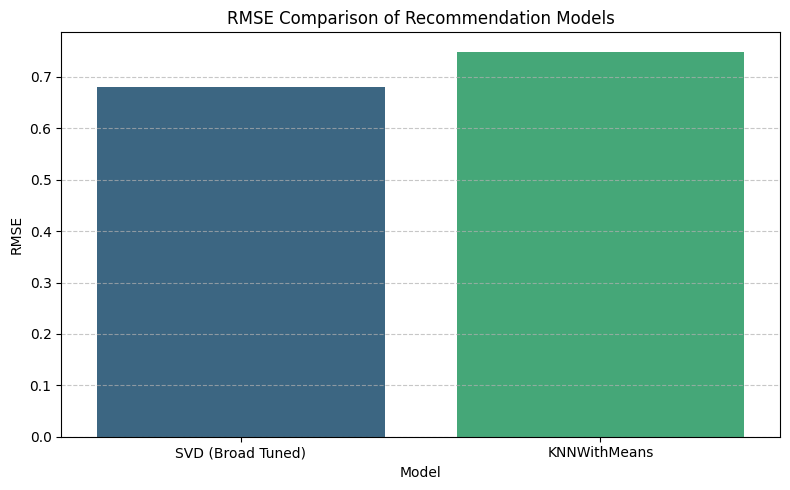

In [23]:
fig1, ax1 = plt.subplots(figsize=(8, 5))
sns.barplot(x='Model', y='RMSE', data=performance_df, palette='viridis', ax=ax1, hue='Model', legend=False)
plt.title('RMSE Comparison of Recommendation Models')
plt.xlabel('Model')
plt.ylabel('RMSE')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


#### 2. Classification Metrics Comparison (Precision, Recall, F1-score, Accuracy)

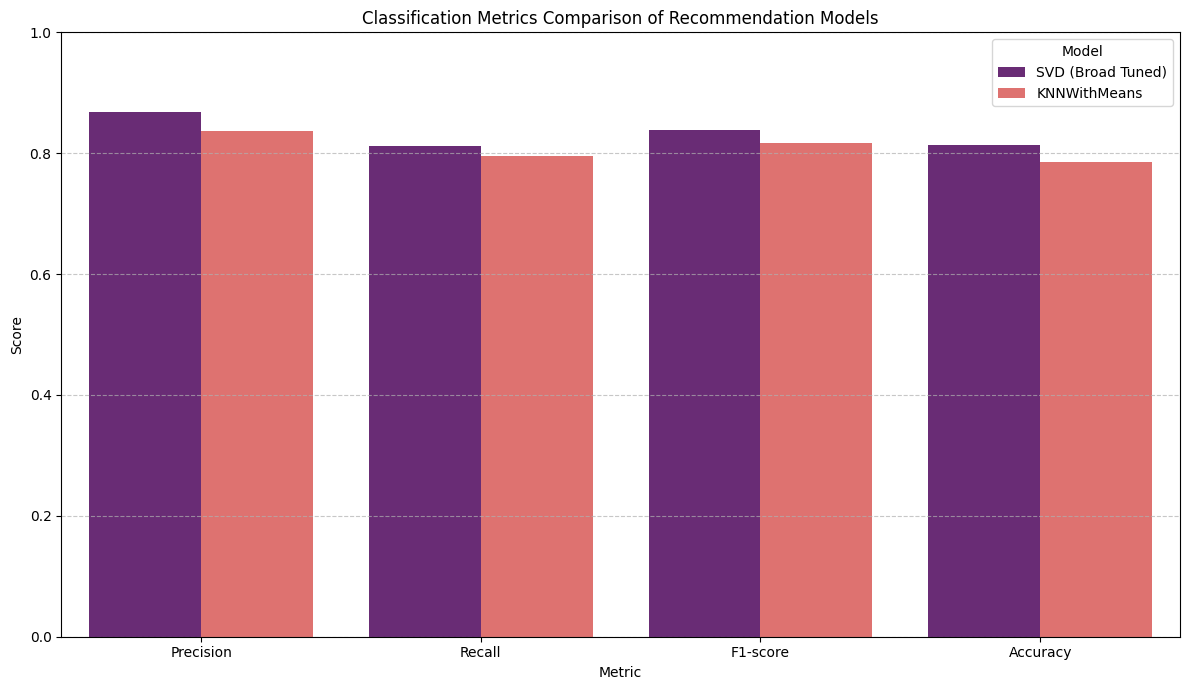

In [24]:
# Prepare data for classification metrics plot
classification_metrics = performance_df.set_index('Model').drop(columns=['RMSE'])
classification_metrics_melted = classification_metrics.reset_index().melt('Model', var_name='Metric', value_name='Score')

fig2, ax2 = plt.subplots(figsize=(12, 7))
sns.barplot(x='Metric', y='Score', hue='Model', data=classification_metrics_melted, palette='magma', ax=ax2)
plt.title('Classification Metrics Comparison of Recommendation Models')
plt.xlabel('Metric')
plt.ylabel('Score')
plt.ylim(0, 1) # Metrics are between 0 and 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


Dashboard Summary
From the visualizations above, we can observe the following:

RMSE: The SVD (Broad Tuned) model generally has a lower RMSE, indicating better accuracy in predicting ratings compared to KNNWithMeans.
Classification Metrics: For Precision, Recall, F1-score, and Accuracy, the SVD (Broad Tuned) model also shows slightly better or comparable performance.

### Build a Gradio Application for Demonstrating Recommendations

In [25]:
# Install Gradio if not already installed
!pip install gradio -q

In [26]:
import gradio as gr

# Define the Gradio function for SVD-based item-item recommendations
def gradio_recommend_similar_movies_svd(movie_title, n_recommendations):
    if not movie_title or movie_title == 'None':
        return pd.DataFrame({'Message': ['Please enter a movie title.']})
    try:
        # Ensure n_recommendations is an integer
        n_recommendations = int(n_recommendations)
        recommendations = get_recommendation_svd(movie_title, n_recommendations)
        if recommendations.empty:
            return pd.DataFrame({'Message': [f"No recommendations found for '{movie_title}'."]})
        return recommendations
    except Exception as e:
        return pd.DataFrame({'Error': [str(e)]})

# Define the Gradio function for user-based SVD recommendations
def gradio_recommend_for_user_svd(user_id, n_recommendations):
    if user_id is None:
        return pd.DataFrame({'Message': ['Please enter a user ID.']})
    try:
        # Ensure user_id and n_recommendations are integers
        user_id = int(user_id)
        n_recommendations = int(n_recommendations)
        recommendations = get_movie_recommendations(user_id, algo_broad, ratings, movies, n_recommendations)
        if recommendations.empty:
            return pd.DataFrame({'Message': [f"No recommendations found for user ID {user_id}."]})
        return recommendations
    except Exception as e:
        return pd.DataFrame({'Error': [str(e)]})

In [27]:
# Create Gradio interfaces for each recommendation type

# Item-item recommendation interface
item_item_interface = gr.Interface(
    fn=gradio_recommend_similar_movies_svd,
    inputs=[
        gr.Textbox(label="Enter Movie Title (e.g., Toy Story (1995))"),
        gr.Slider(minimum=5, maximum=20, value=10, step=1, label="Number of Recommendations")
    ],
    outputs="dataframe",
    title="SVD-Based Item-Item Movie Recommender",
    description="Enter a movie title to get similar movie recommendations based on SVD latent features."
)

# User-based recommendation interface
user_based_interface = gr.Interface(
    fn=gradio_recommend_for_user_svd,
    inputs=[
        gr.Number(label="Enter User ID (e.g., 1)", value=1),
        gr.Slider(minimum=5, maximum=20, value=10, step=1, label="Number of Recommendations")
    ],
    outputs="dataframe",
    title="User-Based SVD Movie Recommender",
    description="Enter a user ID to get personalized movie recommendations based on their predicted ratings from the SVD model."
)

# Combine the interfaces into a TabbedInterface
demo = gr.TabbedInterface([item_item_interface, user_based_interface],
                          ["Item-Item Recommendations (SVD-based)", "User-Based Recommendations (SVD)"])

# Launch the Gradio app
demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://5a5f4493d8e0753d7f.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


### Conclusion

This notebook demonstrates the development of a movie recommendation system using collaborative filtering techniques, specifically SVD and KNNWithMeans. Through data preprocessing, feature engineering, and model training, we built and evaluated these models. The SVD model, after hyperparameter tuning, generally outperformed KNNWithMeans in terms of RMSE and classification metrics. Finally, a Gradio application was integrated to provide a user-friendly interface for demonstrating both item-item and user-based recommendations.

### Future Scope

To further enhance this movie recommendation system, several areas could be explored:

*   **Hybrid Models:** Combine collaborative filtering with content-based filtering (using movie genres, descriptions, or cast information) to improve recommendation diversity and address the cold-start problem more effectively.
*   **Deep Learning Models:** Investigate the use of neural networks, such as Autoencoders or Graph Neural Networks, for more sophisticated latent feature extraction and prediction.
*   **Real-time Recommendations:** Implement a system that can provide real-time recommendations based on a user's current activity or viewing session.
*   **A/B Testing:** Conduct A/B tests to rigorously evaluate the impact of different recommendation algorithms and model configurations on user engagement metrics.
*   **User Interface Enhancements:** Further develop the Gradio application or deploy a more robust web application with additional features like user profiles, rating history, and feedback mechanisms.
*   **Scalability for Large Datasets:** Optimize the models and infrastructure to handle extremely large datasets efficiently, potentially by leveraging distributed computing frameworks.